## ML-Specific Patterns

In [89]:
import numpy as np

In [90]:
# Exercise 8.1

def relu(x: np.ndarray) -> np.ndarray:
    """max(x, 0) element-wise"""
    return np.maximum(0, x)

def leaky_relu(x: np.ndarray, alpha: float = 0.01) -> np.ndarray:
    """x if x > 0 else alpha*x"""
    return np.maximum(x, alpha * x)

def sigmoid(x: np.ndarray) -> np.ndarray:
    """1 / (1 + exp(-x))"""
    return np.where(x >= 0, 1/(1 + np.exp(-x)), np.exp(x) / (1 + np.exp(x)))

def tanh(x: np.ndarray) -> np.ndarray:
    """(exp(x) - exp(-x)) / (exp(x) + exp(-x))"""
    # Use np.tanh but also can do 2 * sigmoid(2 * x) - 1
    return np.tanh(x)

def softmax(x: np.ndarray) -> np.ndarray:
    """exp(x) / sum(exp(x)), stable version, works on 2D batches"""
    shifted = x - x.max(axis=-1, keepdims=True)
    exp_z = np.exp(shifted)
    return exp_z / exp_z.sum(axis=-1, keepdims=True)

def gelu(x: np.ndarray) -> np.ndarray:
    """x * Phi(x) where Phi is standard normal CDF"""
    return 0.5 * x * (1 + np.tanh(np.sqrt(2/np.pi) * (x + 0.044715 * x**3)))


In [91]:
x = np.array([-3, -1, 0, 1, 3], dtype=float)
assert np.all(relu(x) >= 0)
assert relu(np.array([0.0]))[0] == 0.0
assert relu(np.array([5.0]))[0] == 5.0

assert np.all((sigmoid(x) > 0) & (sigmoid(x) < 1))
assert np.isclose(sigmoid(np.array([0.0]))[0], 0.5)

assert np.all((tanh(x) > -1) & (tanh(x) < 1))
assert np.isclose(tanh(np.array([0.0]))[0], 0.0)

batch = np.array([[1.0, 2.0, 3.0], [4.0, 1.0, 2.0]])
sm = softmax(batch)
assert sm.shape == (2, 3)
assert np.allclose(sm.sum(axis=1), [1.0, 1.0])
assert np.all(sm > 0)

In [92]:
# Exercise 8.2

def mse_loss(y_pred: np.ndarray, y_true: np.ndarray) -> float:
    """Mean squared error: mean((y_pred - y_true)^2)"""
    return np.mean((y_pred - y_true) ** 2)

def mae_loss(y_pred: np.ndarray, y_true: np.ndarray) -> float:
    """Mean absolute error: mean(|y_pred - y_true|)"""
    return np.mean(np.abs(y_pred - y_true))

def binary_cross_entropy(y_pred_prob: np.ndarray, y_true: np.ndarray) -> float:
    """
    Binary cross-entropy.
    y_pred_prob: predicted probabilities, shape (n,) values (0, 1)
    y_true: binary labels, shape (n,) values 0 or 1
    """

    eps = 1e-9
    return -np.mean(y_true*np.log(y_pred_prob+eps) + (1-y_true)*np.log(1-y_pred_prob+eps))

def categorical_cross_entropy(y_pred_probs: np.ndarray, y_true_onehot: np.ndarray) -> float:
    """
    Multi-class cross-entropy.
    y_pred_probs: softmax output, shape (n, k)
    y_true_onehot: one-hot labels, shape (n, k)
    """

    eps = 1e-9
    per_sample = -np.sum(y_true_onehot * np.log(y_pred_probs + eps), axis=1)
    return np.mean(per_sample)

def cross_entropy_from_logits(logits: np.ndarray, y_true_labels: np.ndarray) -> float:
    """
    Cross-entropy directly from raw logits (more stable than softmax then log).
    logits: shape (n, k) - raw model output
    y_true_labels: shape (n,) - integer class indices
    """

    row_max = logits.max(axis=1, keepdims=True)
    shifted = logits - row_max
    sum_exp = np.exp(shifted).sum(axis=1, keepdims=True)
    logsumexp = (row_max + np.log(sum_exp)).flatten()
    logits_correct = logits[np.arange(logits.shape[0]), y_true_labels]
    per_example_loss = logsumexp - logits_correct
    return per_example_loss.mean()

In [93]:
y_true_r = np.array([1.0, 2.0, 3.0, 4.0])
y_pred_r = np.array([1.1, 2.9, 3.2, 3.8])

assert np.isclose(mse_loss(y_pred_r, y_true_r), np.mean((y_pred_r - y_true_r)**2))
assert np.isclose(mae_loss(y_pred_r, y_true_r), np.mean(np.abs(y_pred_r - y_true_r)))

y_true_b = np.array([1, 0, 1, 1, 0], dtype=float)
y_pred_b = np.array([0.9, 0.1, 0.8, 0.7, 0.3])
bce = binary_cross_entropy(y_pred_b, y_true_b)
assert bce > 0, "BCE must be positive"
assert bce < 1.0, "BCE should be small for good predictions"

logits_good = np.array([[5.0, 0.0, 0.0], [0.0, 5.0, 0.0]])
logits_bad = np.array([[0.0, 5.0, 0.0], [5.0, 0.0, 0.0]])
labels = np.array([0, 1])
assert cross_entropy_from_logits(logits_good, labels) < cross_entropy_from_logits(logits_bad, labels)


In [94]:
# Exercise 8.3

def mse_gradient(y_pred: np.ndarray, y_true: np.ndarray) -> np.ndarray:
    """
    Gradient of MSE w.r.t. y_pred.
    d(MSE)/d(y_pred) = 2/n * (y_pred - y_true)
    Shape: same as y_pred
    """

    return 2 / y_pred.size * (y_pred - y_true)

def relu_gradient(x: np.ndarray) -> np.ndarray:
    """
    Gradient of ReLU w.r.t. its input.
    1 where x > 0, 0 where x <= 0.
    Shape: same as x
    """

    return np.where(x > 0, 1.0, 0.0)

def linear_layer_gradients(d_out: np.ndarray, x: np.ndarray, W: np.ndarray):
    """
    Gradients for y = x @ W + b.
    d_out: gradient frowing backwards from next layer, shape (n, out)
    x: input to this layer, shape (n, in)
    W: weight matrix, shape (in, out)

    Returns (d_x, d_W, d_b)
    """

    d_x = d_out @ W.T
    d_W = x.T @ d_out
    d_b = d_out.sum(axis=0)
    return (d_x, d_W, d_b)



In [95]:
def numerical_gradient(loss_fn, param, eps=1e-5):
    grad = np.zeros_like(param)
    it = np.nditer(param, flags=["multi_index"])
    while not it.finished:
        idx = it.multi_index
        original = param[idx]
        param[idx] = original + eps
        f_plus = loss_fn()
        param[idx] = original - eps
        f_minus = loss_fn()
        grad[idx] = (f_plus - f_minus) / (2 * eps)
        param[idx] = original
        it.iternext()
    return grad

np.random.seed(42)
x = np.random.randn(4, 3)
W = np.random.randn(3, 5)
b = np.random.randn(5)
y_true = np.random.randn(4, 5)

def loss():
    y_pred = x @ W + b
    return np.mean((y_pred - y_true)**2)

def analytical_dW():
    y_pred = x @ W + b
    d_out = 2 / (4*5) * (y_pred - y_true)
    _, dW, _ = linear_layer_gradients(d_out, x, W)
    return dW

num_grad = numerical_gradient(loss, W)
anal_grad = analytical_dW()
print(np.allclose(num_grad, anal_grad, atol=1e-5))   # should be True

True


In [96]:
# Exercise 8.4

def kmeans(X: np.ndarray, k: int, max_iters: int = 100, seed: int = 42) -> tuple:
    """
    k-means clustering implemented in NumPy.
    
    X: data array, shape (n_samples, n_features)
    k: number of clusters
    max_iters: maximum iterations
    seed: random seed for initialization
    
    Returns: (centroids, labels, inertia_history)
    centroids: shape (k, n_features) — final centroid positions
    labels: shape (n_samples,) — cluster assignment for each sample
    inertia_history: list of inertia at each iteration
    
    Algorithm:
    1. Initialize k centroids by randomly selecting k data points
    2. Assignment step: assign each point to its nearest centroid
       (use vectorized distance computation — no loops over points)
    3. Update step: move each centroid to the mean of its assigned points
    4. Repeat 2-3 until assignments don't change or max_iters reached
    5. Compute inertia: sum of squared distances from each point to its centroid
    """

    np.random.seed(seed)

    centroids = X[np.random.choice(X.shape[0], k, replace=False)].copy()
    interia_history = []

    for _ in range(max_iters):
      diff = X[:, None, :] - centroids[None, :, :]
      dists = np.linalg.norm(diff, axis=2)
      labels = np.argmin(dists, axis=1)
      new_centroids = np.array([X[labels == c].mean(axis=0) for c in range(k)])
      interia_history.append(np.sum((X - centroids[labels])**2))
      if np.allclose(centroids, new_centroids): break
      centroids = new_centroids

    return centroids, labels, interia_history
    

Unique labels: [0 1 2]
Cluster sizes: [50 50 50]
Inertia decreased: True


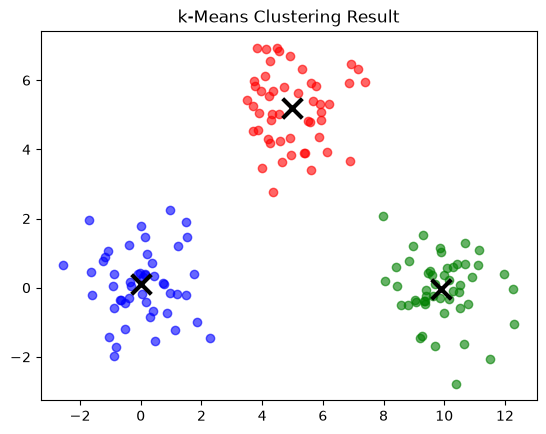

In [97]:
np.random.seed(0)
cluster1 = np.random.randn(50, 2) + np.array([0, 0])
cluster2 = np.random.randn(50, 2) + np.array([5, 5])
cluster3 = np.random.randn(50, 2) + np.array([10, 0])
X = np.vstack([cluster1, cluster2, cluster3])

centroids, labels, history = kmeans(X, k=3)

print(f"Unique labels: {np.unique(labels)}")          # should be [0, 1, 2]
print(f"Cluster sizes: {np.bincount(labels)}")        # should be ~[50, 50, 50]
print(f"Inertia decreased: {history[0] > history[-1]}")

import matplotlib.pyplot as plt
colors = ['red', 'blue', 'green']
for i in range(3):
    mask = labels == i
    plt.scatter(X[mask, 0], X[mask, 1], c=colors[i], alpha=0.6)
plt.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='x', s=200, linewidths=3)
plt.title("k-Means Clustering Result")
plt.show()